<a href="https://colab.research.google.com/github/kardam2806/Respiratory_conditions_ED_Notebook/blob/main/Notebooks/Tidy_resp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install openpyxl
import pandas as pd

# This URL points to the file living in your Raw_Data folder
url = "https://raw.githubusercontent.com/kardam2806/Respiratory_conditions_ED_Notebook/main/Raw_Data/tidy_respiratory_conditions.csv"

df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_end        9240 non-null   object 
 1   condition       9240 non-null   object 
 2   percent_visits  9240 non-null   float64
 3   age_group       9240 non-null   object 
 4   age_min         7920 non-null   float64
 5   age_max         6600 non-null   float64
 6   is_overall      9240 non-null   bool   
dtypes: bool(1), float64(3), object(3)
memory usage: 442.3+ KB


In [3]:
from google.colab import drive
import os
import shutil

# 1. If the folder exists and is causing the error, we force-remove it
if os.path.exists('/content/drive'):
    try:
        # We try to unmount first just to be safe
        drive.flush_and_unmount()
    except:
        pass
    # If it's just an empty folder blocking the way, we delete it
    if not os.path.ismount('/content/drive'):
        shutil.rmtree('/content/drive', ignore_errors=True)

# 2. Now try mounting again
drive.mount('/content/drive', force_remount=True)

# 3. Setup your project path
PROJECT_PATH = '/content/drive/MyDrive/Respiratory_conditions_ED_Notebook'
if os.path.exists(PROJECT_PATH):
    os.chdir(PROJECT_PATH)
    print(f"✅ Success! Working in: {os.getcwd()}")
else:
    print("⚠️ Drive mounted, but I can't find your project folder. Check the name!")

Mounted at /content/drive
✅ Success! Working in: /content/drive/MyDrive/Respiratory_conditions_ED_Notebook


This step imports the file in the collab notebook. The file needs to be loaded in the folder first and its link needs to be copied to load the file

In [4]:
import pandas as pd

# This is the absolute path to your tidy data file
data_path = '/content/drive/MyDrive/Respiratory_conditions_ED_Notebook/tidy_df.csv'

# Read the CSV file
df = pd.read_csv(data_path)

# Verify it loaded by looking at the first 5 rows
print("✅ Data loaded successfully!")
df.head()

✅ Data loaded successfully!


,week_end,condition,percent_visits,age_group,age_min,age_max,is_overall
0,2023-10-07,Acute upper respiratory infection,13.7,Infants 0-1,0.0,1.0,False
1,2023-10-07,Acute upper respiratory infection,11.5,Kids 2-4,2.0,4.0,False
2,2023-10-07,Acute upper respiratory infection,5.1,Kids 5-17,5.0,17.0,False
3,2023-10-07,Acute upper respiratory infection,1.8,Adults 18-49,18.0,49.0,False
4,2023-10-07,Acute upper respiratory infection,1.0,Adults 50-64,50.0,64.0,False


In [5]:
import pandas as pd
df_wide = df.pivot_table(index='week_end',
                   columns=('age_group','condition'),
                   values='percent_visits',
                   aggfunc='sum')

Data wrangling: This step includes the conversion of dataframe from longitudinal data format to wider format for observing easily.
Using pivot_table as the data contains multiple duplicate entries in this dataset.

In [6]:
df_wide.head()

age_group                       Adults 18-49                                 \
condition  Acute upper respiratory infection Bronchiolitis Bronchitis Croup   
week_end                                                                      
2023-10-07                               1.8           0.0        0.7   0.0   
2023-10-14                               1.9           0.0        0.8   0.0   
2023-10-21                               2.0           0.0        0.8   0.0   
2023-10-28                               2.0           0.0        0.9   0.0   
2023-11-04                               2.3           0.0        0.9   0.0   

age_group                                               \
condition  Laryngitis and tracheitis or supraglottitis   
week_end                                                 
2023-10-07                                         0.0   
2023-10-14                                         0.0   
2023-10-21                                         0.0   
2023-10-28                                         0.1   
2023-11-04                                         0.1   

age_group                                                                     \
condition  Other lower respiratory Pneumonia Respiratory distress or failure   
week_end                                                                       
2023-10-07                     0.0       0.7                             0.3   
2023-10-14                     0.0       0.7                             0.3   
2023-10-21                     0.0       0.8                             0.3   
2023-10-28                     0.0       0.8                             0.3   
2023-11-04                     0.0       0.8                             0.3   

age_group                                                        ...  \
condition  Sinus infection Sore throat (including strep throat)  ...   
week_end                                                         ...   
2023-10-07             0.3                                  1.9  ...   
2023-10-14             0.3                                  1.9  ...   
2023-10-21             0.4                                  2.0  ...   
2023-10-28             0.4                                  2.0  ...   
2023-11-04             0.4                                  2.1  ...   

age_group    Seniors 65+                   \
condition  Bronchiolitis Bronchitis Croup   
week_end                                    
2023-10-07           0.0        0.7   0.0   
2023-10-14           0.0        0.7   0.0   
2023-10-21           0.0        0.8   0.0   
2023-10-28           0.1        0.8   0.0   
2023-11-04           0.1        0.8   0.0   

age_group                                               \
condition  Laryngitis and tracheitis or supraglottitis   
week_end                                                 
2023-10-07                                         0.0   
2023-10-14                                         0.0   
2023-10-21                                         0.0   
2023-10-28                                         0.0   
2023-11-04                                         0.0   

age_group                                                                     \
condition  Other lower respiratory Pneumonia Respiratory distress or failure   
week_end                                                                       
2023-10-07                     0.0       3.5                             2.9   
2023-10-14                     0.0       3.6                             3.0   
2023-10-21                     0.0       3.6                             3.0   
2023-10-28                     0.0       3.6                             2.9   
2023-11-04                     0.0       3.7                             3.0   

age_group                                                                    
condition  Sinus infection Sore throat (including strep throat) Tonsillitis  
week_end                                                     

In [7]:
df_wide.index = pd.to_datetime(df_wide.index)
df_monthly = df_wide.resample('ME').mean()
df_monthly.index = df_monthly.index.to_period('M')
print(df_monthly)


age_group                      Adults 18-49                                 \
condition Acute upper respiratory infection Bronchiolitis Bronchitis Croup   
week_end                                                                     
2023-10                               1.925         0.000   0.800000   0.0   
2023-11                               2.425         0.025   1.000000   0.0   
2023-12                               3.020         0.100   1.140000   0.0   
2024-01                               2.650         0.050   1.025000   0.0   
2024-02                               2.275         0.000   0.800000   0.0   
2024-03                               1.980         0.000   0.780000   0.0   
2024-04                               1.650         0.000   0.725000   0.0   
2024-05                               1.475         0.000   0.675000   0.0   
2024-06                               1.160         0.000   0.540000   0.0   
2024-07                               1.025         0.000   0.40

Dataset with time/date column is treated as string. Hence, it is therefore converted further using .dt version to further wrangle data into monthly format.


In [8]:
df_wide = df_monthly.reset_index()
df_wide.head()

age_group week_end                      Adults 18-49                           \
condition          Acute upper respiratory infection Bronchiolitis Bronchitis   
0          2023-10                             1.925         0.000      0.800   
1          2023-11                             2.425         0.025      1.000   
2          2023-12                             3.020         0.100      1.140   
3          2024-01                             2.650         0.050      1.025   
4          2024-02                             2.275         0.000      0.800   

age_group                                                    \
condition Croup Laryngitis and tracheitis or supraglottitis   
0           0.0                                       0.025   
1           0.0                                       0.100   
2           0.0                                       0.100   
3           0.0                                       0.050   
4           0.0                                       0.050   

age_group                                                                    \
condition Other lower respiratory Pneumonia Respiratory distress or failure   
0                             0.0     0.750                           0.300   
1                             0.0     0.900                           0.300   
2                             0.0     1.080                           0.360   
3                             0.0     1.075                           0.375   
4                             0.0     0.975                           0.350   

age_group                  ...   Seniors 65+                   \
condition Sinus infection  ... Bronchiolitis Bronchitis Croup   
0                   0.350  ...         0.025      0.750   0.0   
1                   0.400  ...         0.100      0.900   0.0   
2                   0.480  ...         0.220      1.220   0.0   
3                   0.450  ...         0.200      1.150   0.0   
4                   0.425  ...         0.100      0.875   0.0   

age_group                                                                      \
condition Laryngitis and tracheitis or supraglottitis Other lower respiratory   
0                                                 0.0                     0.0   
1                                                 0.0                     0.0   
2                                                 0.0                     0.0   
3                                                 0.0                     0.0   
4                                                 0.0                     0.0   

age_group                                                            \
condition Pneumonia Respiratory distress or failure Sinus infection   
0             3.575                           2.950           0.200   
1             3.925                           3.125           0.200   
2             4.660                           3.600           0.240   
3             4.925                           3.750           0.250   
4             4.175                           3.400           0.225   

age_group                                                   
condition Sore throat (including strep throat) Tonsillitis  
0                                        0.300         0.0  
1                                        0.350         0.0  
2                                        0.440         0.0  
3                                        0.375         0.0  
4                                        0.350         0.0  

[5 rows x 78 columns]

In [9]:
# 1. Start with your long-format data
df_long = df_wide.set_index('week_end').stack(level=[0,1]).reset_index()
df_long.columns = ['week_end', 'age_group', 'condition', 'value']

# 2. Pivot: Define what stays as rows (index) and what moves to columns
df_final = df_long.pivot(index=['age_group', 'week_end'],
                         columns='condition',
                         values='value')

# 3. Optional: Sort to keep age groups grouped together
df_final = df_final.sort_index()

df_final.head()

/tmp/ipykernel_5339/4030323359.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = df_wide.set_index('week_end').stack(level=[0,1]).reset_index()


condition              Acute upper respiratory infection  Bronchiolitis  \
age_group    week_end                                                     
Adults 18-49 2023-10                               1.925          0.000   
             2023-11                               2.425          0.025   
             2023-12                               3.020          0.100   
             2024-01                               2.650          0.050   
             2024-02                               2.275          0.000   

condition              Bronchitis  Croup  \
age_group    week_end                      
Adults 18-49 2023-10        0.800    0.0   
             2023-11        1.000    0.0   
             2023-12        1.140    0.0   
             2024-01        1.025    0.0   
             2024-02        0.800    0.0   

condition              Laryngitis and tracheitis or supraglottitis  \
age_group    week_end                                                
Adults 18-49 2023-10                                         0.025   
             2023-11                                         0.100   
             2023-12                                         0.100   
             2024-01                                         0.050   
             2024-02                                         0.050   

condition              Other lower respiratory  Pneumonia  \
age_group    week_end                                       
Adults 18-49 2023-10                       0.0      0.750   
             2023-11                       0.0      0.900   
             2023-12                       0.0      1.080   
             2024-01                       0.0      1.075   
             2024-02                       0.0      0.975   

condition              Respiratory distress or failure  Sinus infection  \
age_group    week_end                                                     
Adults 18-49 2023-10                             0.300            0.350   
             2023-11                             0.300            0.400   
             2023-12                             0.360            0.480   
             2024-01                             0.375            0.450   
             2024-02                             0.350            0.425   

condition              Sore throat (including strep throat)  Tonsillitis  
age_group    week_end                                                     
Adults 18-49 2023-10                                  1.950        0.200  
             2023-11                                  2.225        0.225  
             2023-12                                  2.460        0.240  
             2024-01                                  2.275        0.200  
             2024-02                                  2.325        0.225

- Data which needs to be displayed in columns vertically that needs to be under columns whereas the one wants to arrange as rows, it needs to be passed under index (index='age_group', 'week_end') this will display as above.

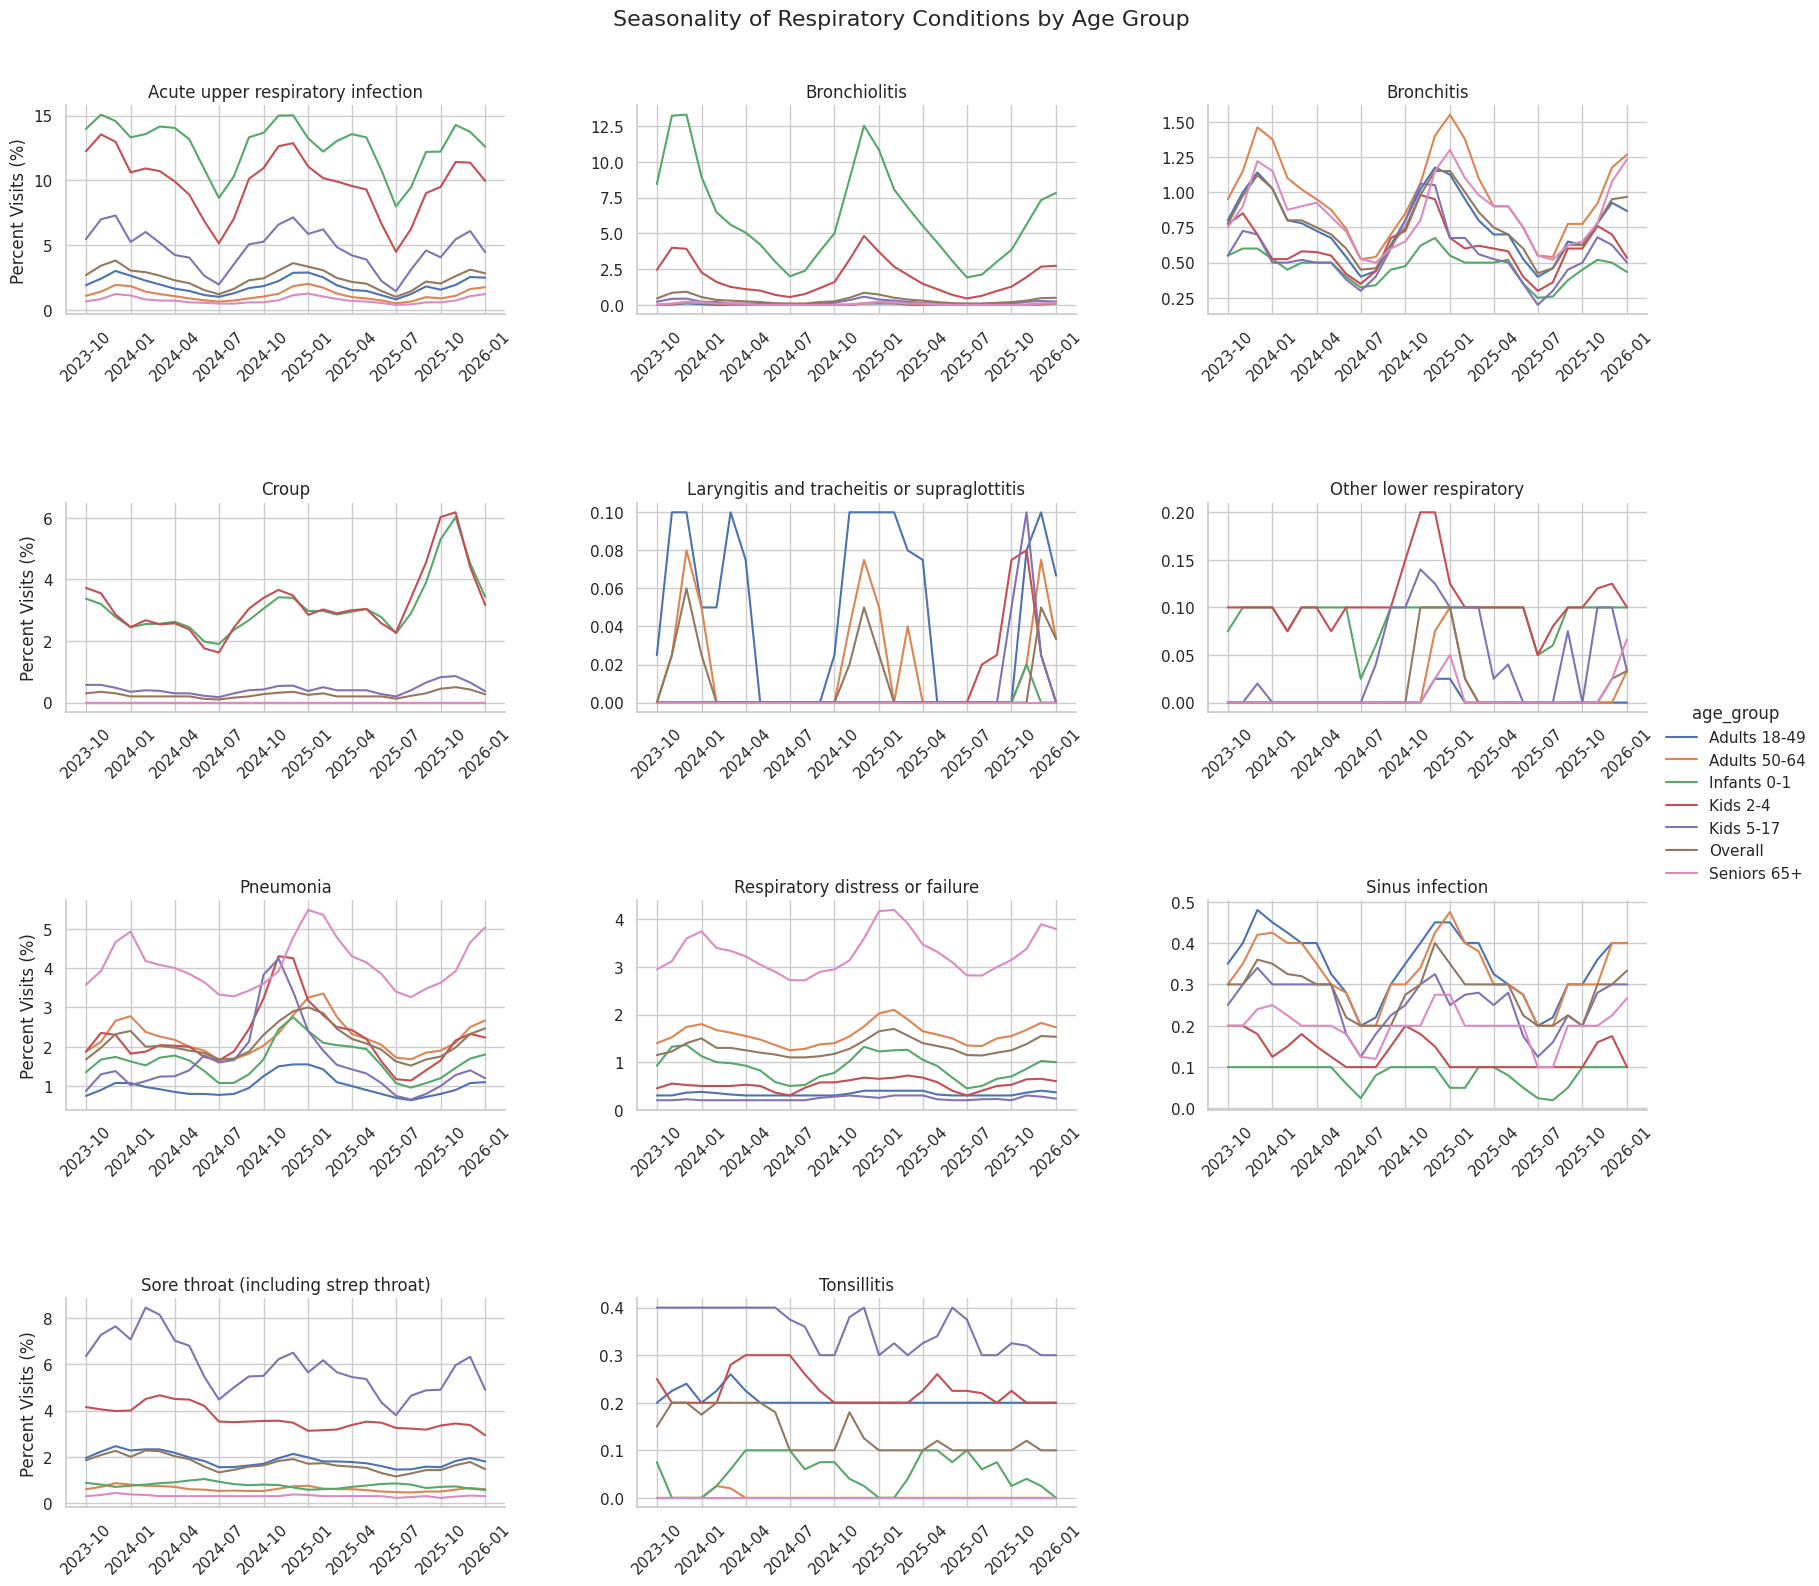

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the copy
df_plot = df_final.copy()

# 2. Reset the index
df_plot = df_plot.reset_index()

# 3. Melt the data
df_long_plot = df_plot.melt(
    id_vars=['week_end', 'age_group'],
    var_name='Condition',
    value_name='Percent_Visits'
)

# 4. FIX: Convert PeriodDtype to Timestamp
# This turns periods into plot-friendly dates:
if isinstance(df_long_plot['week_end'].iloc[0], pd.Period):
    df_long_plot['week_end'] = df_long_plot['week_end'].dt.to_timestamp()
else:
    df_long_plot['week_end'] = pd.to_datetime(df_long_plot['week_end'])

# 5. Create the Facet Plot
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df_long_plot,
    x='week_end',
    y='Percent_Visits',
    hue='age_group',
    col='Condition',
    kind='line',
    col_wrap=3,
    height=4,
    aspect=1.4,
    facet_kws={'sharey': False, 'sharex': False}
)

g.set_titles("{col_name}", pad=50, fontweight='bold') # Added 'pad' to push title away from the plot

# hspace: vertical space between rows
# wspace: horizontal space between columns
plt.subplots_adjust(top=0.9, hspace=0.9, wspace=0.3)

g.set_axis_labels("", "Percent Visits (%)")

# 6. Formatting
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Seasonality of Respiratory Conditions by Age Group', fontsize=16)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.show()

Statistic Summary:

In [11]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

stats_results = []

# Loop through each conditions:
for condition in df_long_plot['Condition'].unique():
    subset = df_long_plot[df_long_plot['Condition'] == condition]

    # ANOVA: Does Age Group significantly affect Percent_Visits?
    groups = [group['Percent_Visits'].values for name, group in subset.groupby('age_group')]
    f_stat, p_val = stats.f_oneway(*groups)


    # Using a simple OLS model to get R-squared
    model = ols('Percent_Visits ~ C(age_group)', data=subset).fit()
    r_sq = model.rsquared

    stats_results.append({
        'Condition': condition,
        'F-Statistic': round(f_stat, 3),
        'P-Value': round(p_val, 4),
        'R-Squared (Age Impact)': round(r_sq, 3),
        'Significant?': 'Yes' if p_val < 0.05 else 'No'
    })

# Create Summary DataFrame
df_stats_summary = pd.DataFrame(stats_results)
print(df_stats_summary)

                                      Condition  F-Statistic  P-Value  \
0             Acute upper respiratory infection      339.954      0.0   
1                                 Bronchiolitis       78.340      0.0   
2                                    Bronchitis       19.586      0.0   
3                                         Croup      215.135      0.0   
4   Laryngitis and tracheitis or supraglottitis       13.477      0.0   
5                       Other lower respiratory       65.799      0.0   
6                                     Pneumonia       76.768      0.0   
7               Respiratory distress or failure      628.736      0.0   
8                               Sinus infection       83.089      0.0   
9          Sore throat (including strep throat)      446.131      0.0   
10                                  Tonsillitis      499.561      0.0   

    R-Squared (Age Impact) Significant?  
0                    0.915          Yes  
1                    0.713          Yes

In [12]:
from google.colab import files

# Save DataFrame as Excel
df_final.to_excel('df_final.xlsx', index=True)

# Download
#files.download('df_final.xlsx')

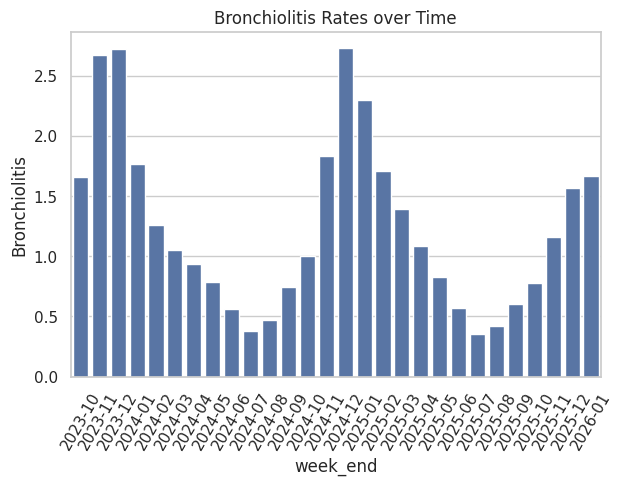

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use y='Bronchiolitis' with a Capital 'B'
sns.barplot(data=df_final,
            x='week_end',
            y='Bronchiolitis',
            errorbar=None)


plt.xticks(rotation=60)
plt.tight_layout()
plt.title("Bronchiolitis Rates over Time")
plt.show()


- If one condition vs time needs to displayed then above code works. While the need to display multiple disease vs time graph requires melting of data.

In [14]:
# Checking the df gives a check on whether the change is as per desired expectation:
df_final.head()


condition              Acute upper respiratory infection  Bronchiolitis  \
age_group    week_end                                                     
Adults 18-49 2023-10                               1.925          0.000   
             2023-11                               2.425          0.025   
             2023-12                               3.020          0.100   
             2024-01                               2.650          0.050   
             2024-02                               2.275          0.000   

condition              Bronchitis  Croup  \
age_group    week_end                      
Adults 18-49 2023-10        0.800    0.0   
             2023-11        1.000    0.0   
             2023-12        1.140    0.0   
             2024-01        1.025    0.0   
             2024-02        0.800    0.0   

condition              Laryngitis and tracheitis or supraglottitis  \
age_group    week_end                                                
Adults 18-49 2023-10                                         0.025   
             2023-11                                         0.100   
             2023-12                                         0.100   
             2024-01                                         0.050   
             2024-02                                         0.050   

condition              Other lower respiratory  Pneumonia  \
age_group    week_end                                       
Adults 18-49 2023-10                       0.0      0.750   
             2023-11                       0.0      0.900   
             2023-12                       0.0      1.080   
             2024-01                       0.0      1.075   
             2024-02                       0.0      0.975   

condition              Respiratory distress or failure  Sinus infection  \
age_group    week_end                                                     
Adults 18-49 2023-10                             0.300            0.350   
             2023-11                             0.300            0.400   
             2023-12                             0.360            0.480   
             2024-01                             0.375            0.450   
             2024-02                             0.350            0.425   

condition              Sore throat (including strep throat)  Tonsillitis  
age_group    week_end                                                     
Adults 18-49 2023-10                                  1.950        0.200  
             2023-11                                  2.225        0.225  
             2023-12                                  2.460        0.240  
             2024-01                                  2.275        0.200  
             2024-02                                  2.325        0.225

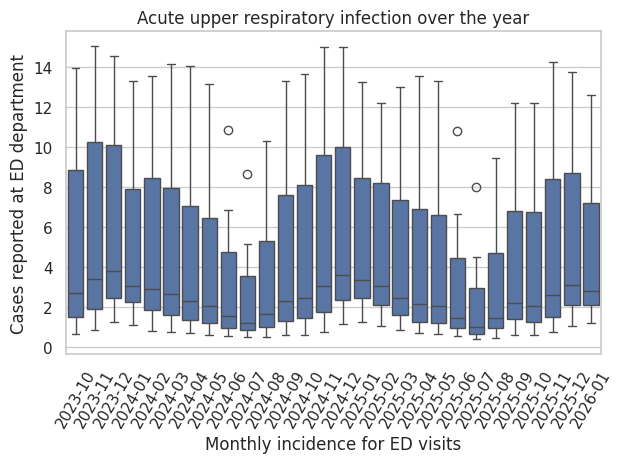

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Plotting box plot gives idea about the median values and outliers in the df:
sns.boxplot(data=df_final,
            x='week_end',
            y='Acute upper respiratory infection')
plt.title('Acute upper respiratory infection over the year')
plt.xlabel('Monthly incidence for ED visits')
plt.ylabel('Cases reported at ED department')
# rotation allows better readability of text.
plt.tick_params(axis='x', rotation=60)

# Tight layout is very essential when one wants the edges defined for multiple graphs and to avoid graph text overlapping:
plt.tight_layout()
plt.show()




- Boxplot offers visualization opportunity to understand the data including outlier, but visually not backed by any numbers.
- In order to draw inference, statistical figure is extremely important which is calculated further.

In [16]:
# To print count, mean, std, min, 25%, 50%(median), 75%, and max
print(df_final['Acute upper respiratory infection'].describe())

mean_val = df_final['Acute upper respiratory infection'].mean()
std_val = df_final['Acute upper respiratory infection'].std()
median_val = df_final['Acute upper respiratory infection'].median()
variance_val = df_final['Acute upper respiratory infection'].var()

print(f"Mean: {mean_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Variance: {variance_val:.2f}")

count    196.000000
mean       4.808656
std        4.542591
min        0.400000
25%        1.240000
50%        2.585000
75%        8.162500
max       15.075000
Name: Acute upper respiratory infection, dtype: float64
Mean: 4.81
Standard Deviation: 4.54
Median: 2.58
Variance: 20.64


- The difference between Mean(4.81) and Median(2.58) is large. This provides enough evidence to believe that there were hotspots in timeline when the  'Acute Upper Respiratory Infection' cases were reported higher than average in comparision to several weekends.

To plot for multiple conditions; dataframe needs to be melted and reorganised as required.

In [17]:
# checking how the dataframe looks like to proceed the melting as required:
df_final.head()

condition              Acute upper respiratory infection  Bronchiolitis  \
age_group    week_end                                                     
Adults 18-49 2023-10                               1.925          0.000   
             2023-11                               2.425          0.025   
             2023-12                               3.020          0.100   
             2024-01                               2.650          0.050   
             2024-02                               2.275          0.000   

condition              Bronchitis  Croup  \
age_group    week_end                      
Adults 18-49 2023-10        0.800    0.0   
             2023-11        1.000    0.0   
             2023-12        1.140    0.0   
             2024-01        1.025    0.0   
             2024-02        0.800    0.0   

condition              Laryngitis and tracheitis or supraglottitis  \
age_group    week_end                                                
Adults 18-49 2023-10                                         0.025   
             2023-11                                         0.100   
             2023-12                                         0.100   
             2024-01                                         0.050   
             2024-02                                         0.050   

condition              Other lower respiratory  Pneumonia  \
age_group    week_end                                       
Adults 18-49 2023-10                       0.0      0.750   
             2023-11                       0.0      0.900   
             2023-12                       0.0      1.080   
             2024-01                       0.0      1.075   
             2024-02                       0.0      0.975   

condition              Respiratory distress or failure  Sinus infection  \
age_group    week_end                                                     
Adults 18-49 2023-10                             0.300            0.350   
             2023-11                             0.300            0.400   
             2023-12                             0.360            0.480   
             2024-01                             0.375            0.450   
             2024-02                             0.350            0.425   

condition              Sore throat (including strep throat)  Tonsillitis  
age_group    week_end                                                     
Adults 18-49 2023-10                                  1.950        0.200  
             2023-11                                  2.225        0.225  
             2023-12                                  2.460        0.240  
             2024-01                                  2.275        0.200  
             2024-02                                  2.325        0.225

,week_end,Condition,Rate
0,2023-10,Acute upper respiratory infection,1.925
1,2023-11,Acute upper respiratory infection,2.425
2,2023-12,Acute upper respiratory infection,3.020
3,2024-01,Acute upper respiratory infection,2.650
4,2024-02,Acute upper respiratory infection,2.275


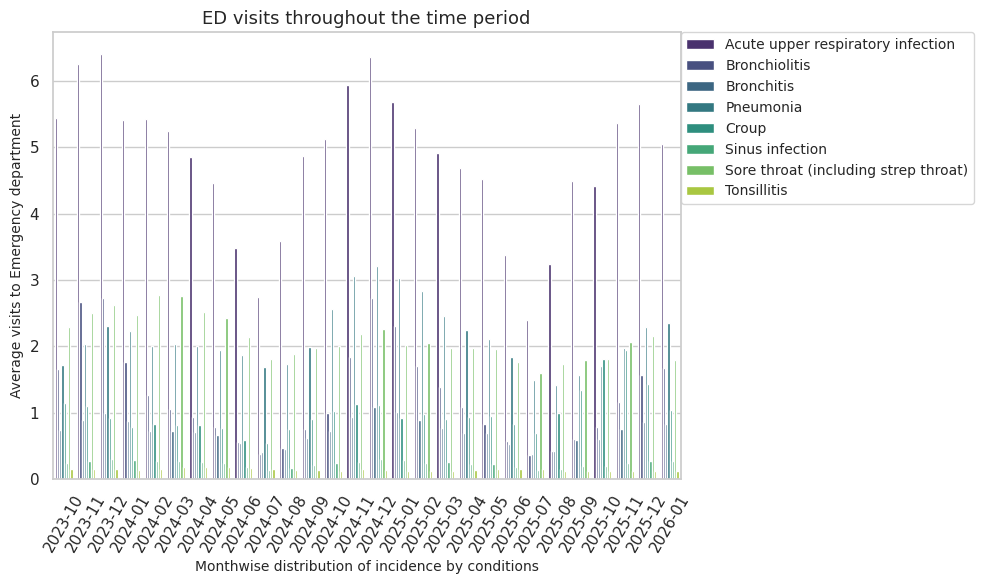

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("df_final.xlsx")
# when using processed data, use the file generated and also put within double quotes.

# 2. Identify the condition columns you want to plot and the strip function to ignore spaces which lead to keyword error.
# Stripping would remove the error that could be because of spacing and other.
df.columns = df.columns.str.strip()
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

# 3 Melt the data into long format for plotting:

df_melted = pd.melt(df, id_vars=['week_end'],
                    value_vars=condition_cols,
                    var_name='Condition',
                    value_name='Rate')


# plotting the bar chart with multiple conditions:
plt.figure(figsize=(10,6))
sns.barplot(df_melted, x= 'week_end',
                y= 'Rate',
                hue='Condition',
                errorbar=None,
                palette='viridis',
                )

# Defining the legend will anchor the box inside or outside the graph borders.
plt.legend(bbox_to_anchor=(1.0,1.0), loc='upper left', borderaxespad=0, fontsize='10')
plt.ylabel('Average visits to Emergency department', fontsize = 10)
plt.xlabel('Monthwise distribution of incidence by conditions', fontsize = 10)
plt.title('ED visits throughout the time period', fontsize = 13)
plt.xticks(rotation=60)
plt.tight_layout()
df_melted.head()

In [19]:
# Get a custom list of stats for each illness
custom_stats = df_melted.groupby('Condition')['Rate'].agg(['mean', 'median', 'std', 'var'])

print(custom_stats)

                                          mean  median       std        var
Condition                                                                  
Acute upper respiratory infection     4.808656  2.5850  4.542591  20.635132
Bronchiolitis                         1.250136  0.1500  2.498740   6.243703
Bronchitis                            0.715408  0.6750  0.265625   0.070557
Croup                                 0.998002  0.2000  1.468228   2.155694
Pneumonia                             2.130638  1.8900  1.070966   1.146969
Sinus infection                       0.232321  0.2200  0.108420   0.011755
Sore throat (including strep throat)  2.116080  1.5675  1.933393   3.738009
Tonsillitis                           0.139617  0.1000  0.126365   0.015968


Summary statistic:
1. Acute upper respiratory infections dominate ED visits with a mean of 4.81, showing significant volatility and outbreak patterns due to high variance of 20.64.
2. In contrast, conditions like sinus infections and Tonsilitis remain highly stable and predictable, maintaining consistently low incidence rates throughout the period.

/tmp/ipykernel_5339/3367408685.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


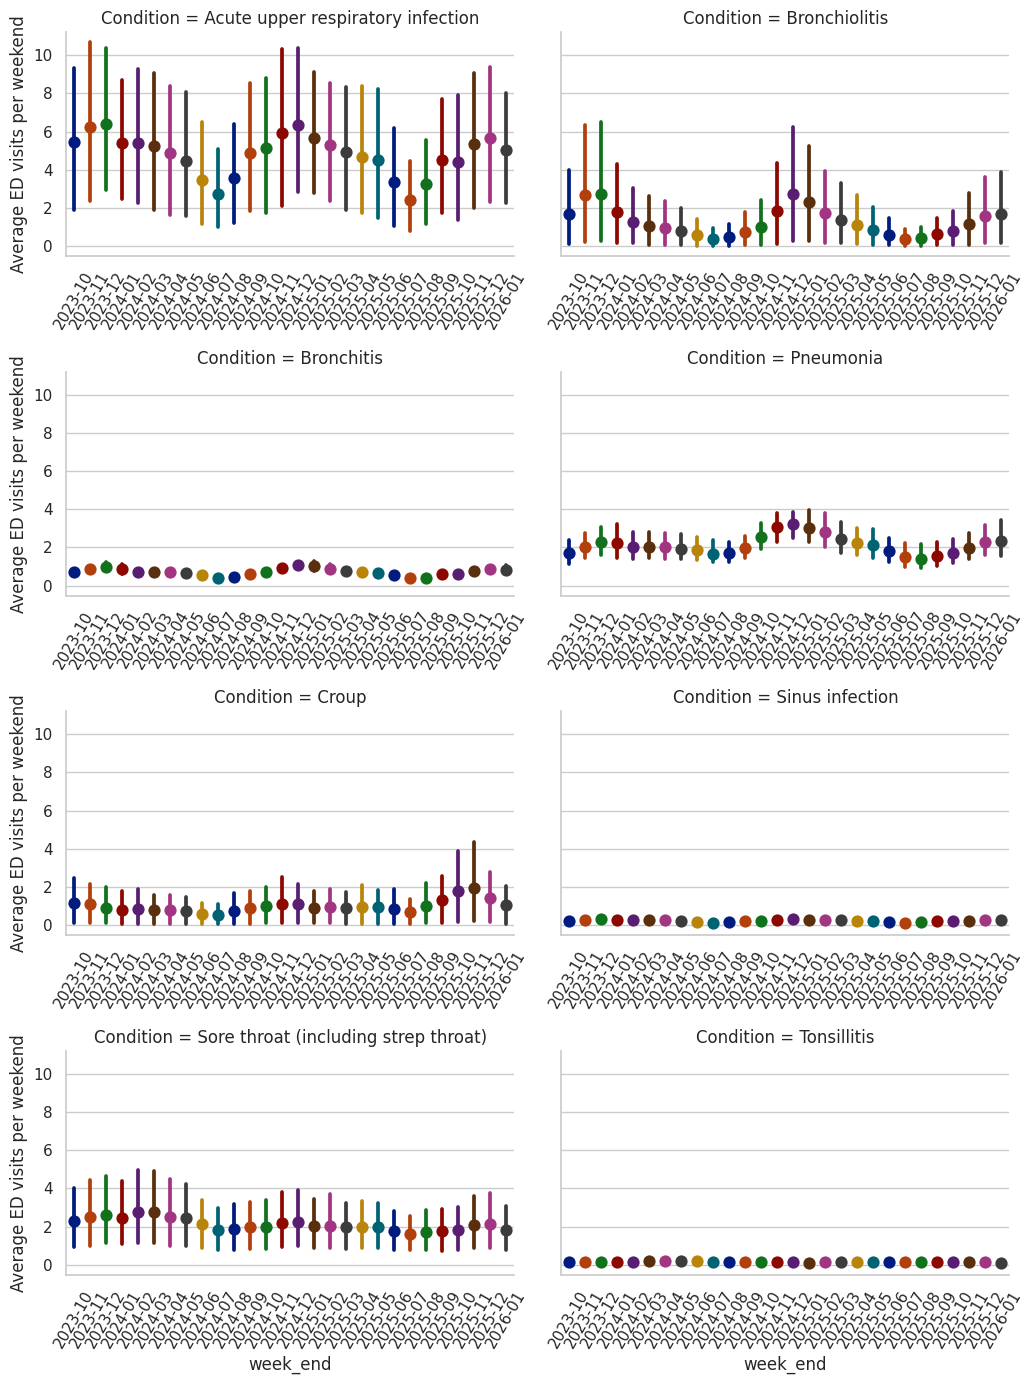

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("df_final.xlsx")
# when using processed data, use the file generated and also put within double quotes.

# 2. Identify the condition columns you want to plot and the strip function to ignore spaces which lead to keyword error.
df.columns = df.columns.str.strip()
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

# 3 Melt the data into long format for plotting:

df_melted = pd.melt(df, id_vars=['week_end'],
                    value_vars=condition_cols,
                    var_name='Condition',
                    value_name='Average ED visits per weekend')

g = sns.catplot(
    data=df_melted,
    x='week_end',
    y='Average ED visits per weekend',
    col='Condition',
    kind='point',
    col_wrap=2,
    height=3.5,
    aspect=1.5,
    palette='dark',
    sharex=False
)

g.set_xticklabels(rotation=60)
g.tight_layout()


1. The facet plots further backs the claim to support the findings of statistics.
2. Additionally, these plots provides evidence of seasonal outbreak of Bronchiolitis and Pneumonia by the way pattern in its incidence.

In [21]:
# Converting the data to datetime format allows interconversion of data to either year or months:
df['week_end'] = pd.to_datetime(df_melted['week_end'], errors='coerce')
df.head()

df['Year'] = df['week_end'].dt.year
df.head()

df_clean = df.dropna(subset=['week_end']).copy()
df_clean.head()


,age_group,week_end,Acute upper respiratory infection,Bronchiolitis,Bronchitis,Croup,Laryngitis and tracheitis or supraglottitis,Other lower respiratory,Pneumonia,Respiratory distress or failure,Sinus infection,Sore throat (including strep throat),Tonsillitis,Year
0,Adults 18-49,2023-10-01,1.925,0.000,0.800,0.0,0.025,0.0,0.750,0.300,0.350,1.950,0.200,2023
1,NaN,2023-11-01,2.425,0.025,1.000,0.0,0.100,0.0,0.900,0.300,0.400,2.225,0.225,2023
2,NaN,2023-12-01,3.020,0.100,1.140,0.0,0.100,0.0,1.080,0.360,0.480,2.460,0.240,2023
3,NaN,2024-01-01,2.650,0.050,1.025,0.0,0.050,0.0,1.075,0.375,0.450,2.275,0.200,2024
4,NaN,2024-02-01,2.275,0.000,0.800,0.0,0.050,0.0,0.975,0.350,0.425,2.325,0.225,2024


Plotting line graph to analyse how the "Wave" looked like?


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a list that could be passed to draw trend further:
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

# Melting data rearranges the columns into row format by id vars argument and assigns the value in a seperate column using value_var argument.
df_melted_yearly = pd.melt(df_clean, id_vars='Year',
                    value_vars=condition_cols,
                    var_name='Condition',
                    value_name='Rate')
df_melted_yearly.head()



,Year,Condition,Rate
0,2023,Acute upper respiratory infection,1.925
1,2023,Acute upper respiratory infection,2.425
2,2023,Acute upper respiratory infection,3.020
3,2024,Acute upper respiratory infection,2.650
4,2024,Acute upper respiratory infection,2.275


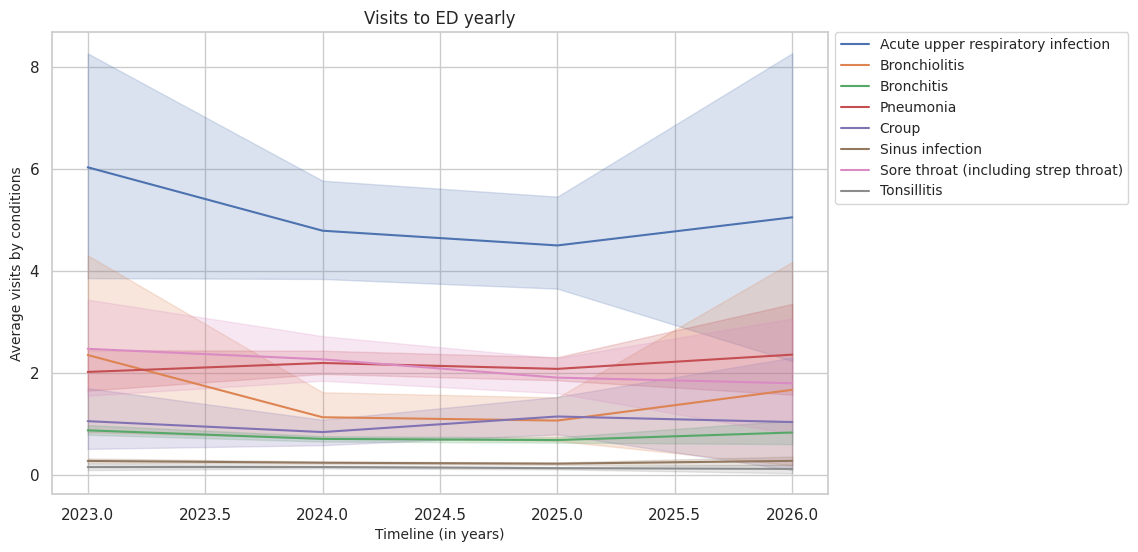

In [23]:
# Plotting the line graph for yearwise prevalence:
plt.figure(figsize=(10,6))
sns.lineplot(df_melted_yearly,
             x='Year',
             y='Rate',
             hue='Condition')

# Adjusting the legend box outside the graph:
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='10')

# Adding labels to x and y axis:
plt.ylabel('Average visits by conditions', fontsize = 10)
plt.xlabel('Timeline (in years)', fontsize = 10)
plt.title('Visits to ED yearly')
plt.show()

Progress note:
Problems addressed:
1. What was the "Disease of the Year"? - Acute Upper Respiratory Infection
2. What did the "Wave" look like? - Fairly stable with peak timezones(month) and three out of all diseases shows upward trend at during last year in dataframe.
3. What was the most common illness overall? 1. Acute Upper Respiratory Infection

Methods used:
1. Histogram to check indicence rate of specific disease.
2. Barplot to determine median range of visits for a particular disease.
3. Catplot to characterize condition wise ED visits throughout the period to define the hotspot timezones when the conditions are at peak.
4. Line chart to analyze the pattern of incidence that lead to x number of visits to Emergency department during the time period.


Aim: To analyze which disease was the 'Disease of the year'?

In [24]:
# 1. Group by Year and Condition to find the average Rate
yearly_rank = df_melted_yearly.groupby(['Year', 'Condition'])['Rate'].mean().reset_index()

# 2. Sorting by rate and picking the highest one
disease_of_the_year = yearly_rank.sort_values(['Year', 'Rate'], ascending=[True, False]).groupby('Year').head(1).reset_index(drop=True)

print("--- Disease of the Year ---")
print(disease_of_the_year)

--- Disease of the Year ---
   Year                          Condition      Rate
0  2023  Acute upper respiratory infection  6.034762
1  2024  Acute upper respiratory infection  4.789762
2  2025  Acute upper respiratory infection  4.500714
3  2026  Acute upper respiratory infection  5.052381


In [25]:
# Grouping the data according to age to see which group is most affected:

#cleaning the data and averaging the mean groupwise considering numeric value only:
df_age = df_clean.groupby(['age_group','week_end']).mean(numeric_only=True).reset_index()

df_age.head()

,age_group,week_end,Acute upper respiratory infection,Bronchiolitis,Bronchitis,Croup,Laryngitis and tracheitis or supraglottitis,Other lower respiratory,Pneumonia,Respiratory distress or failure,Sinus infection,Sore throat (including strep throat),Tonsillitis,Year
0,Adults 18-49,2023-10-01,1.925,0.000,0.800,0.000,0.025,0.000,0.750,0.300,0.35,1.950,0.200,2023.0
1,Adults 50-64,2023-10-01,1.100,0.000,0.950,0.000,0.000,0.000,1.875,1.400,0.30,0.600,0.000,2023.0
2,Infants 0-1,2023-10-01,13.975,8.450,0.550,3.375,0.000,0.075,1.350,0.925,0.10,0.875,0.075,2023.0
3,Kids 2-4,2023-10-01,12.250,2.450,0.775,3.725,0.000,0.100,1.875,0.450,0.20,4.150,0.250,2023.0
4,Kids 5-17,2023-10-01,5.475,0.225,0.550,0.575,0.000,0.000,0.875,0.200,0.25,6.350,0.400,2023.0


Aim: To analyze which group was hit the hardest:

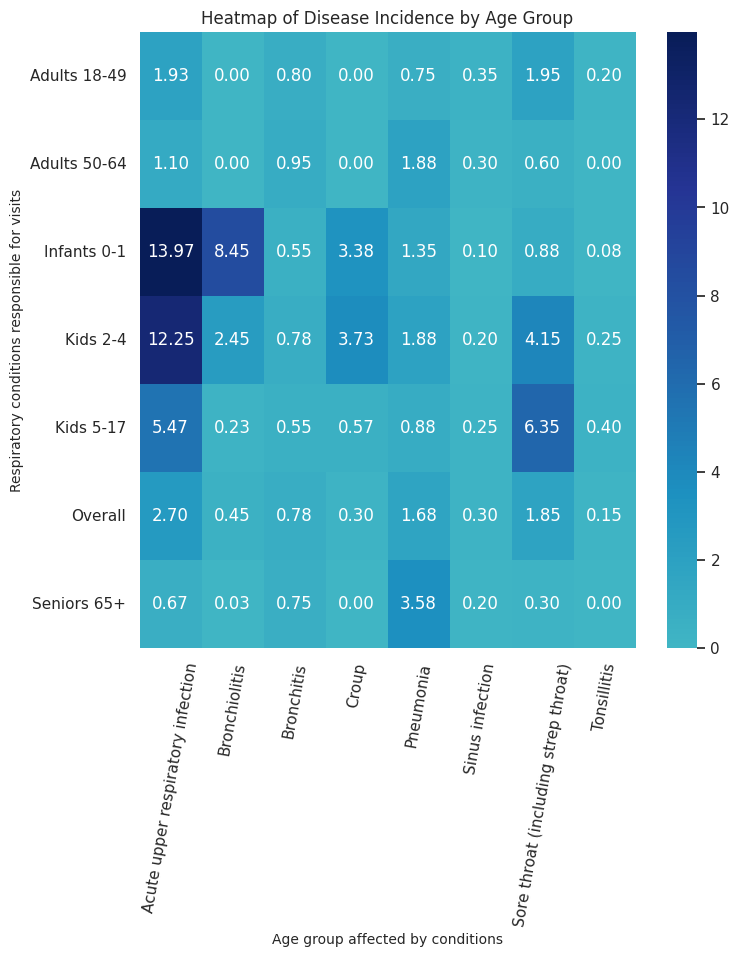

In [26]:
# Analyzing the groupwise affected trend:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Melting the data to bring condition into single column:
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

df_melted_groupwise = pd.melt(df_age, id_vars=['age_group', 'Year'],
                              value_vars= condition_cols,
                              var_name='Condition',
                              value_name='Rate')
df_melted_groupwise.head()

if 'Year' in df_melted_groupwise.columns:
    df_numeric = df_melted_groupwise.drop(columns=['Year'])

# To generate heatmap and groupwise comparision, matrix conversion is important:
df_matrix = df_melted_groupwise.pivot_table(index='age_group',
                                            columns='Condition',
                                            values='Rate',
                                            aggfunc='mean')
df_matrix.head()

# Now plot the pivot table
plt.figure(figsize=(8, 8))
sns.heatmap(df_matrix, annot=True, cmap='YlGnBu', fmt=".2f", center=0)
plt.title('Heatmap of Disease Incidence by Age Group')
plt.ylabel('Respiratory conditions responsible for visits', fontsize=10)
plt.xlabel('Age group affected by conditions', fontsize = 10)
plt.xticks(rotation=80)
plt.yticks(rotation=0)
plt.show()
#



* The dark blue 8.4 for Infants 0-1 means they have a significantly higher rate
of ED visits for Bronchiolitis than any other group, as their smaller airways make this infection much more severe. Since the rate is 0 for adults, it confirms this is almost exclusively a pediatric emergency issue that rarely affects older populations.

In [27]:
df_matrix.head()

Condition,Acute upper respiratory infection,Bronchiolitis,Bronchitis,Croup,Pneumonia,Sinus infection,Sore throat (including strep throat),Tonsillitis
age_group,,,,,,,,
Adults 18-49,1.925,0.000,0.800,0.000,0.750,0.35,1.950,0.200
Adults 50-64,1.100,0.000,0.950,0.000,1.875,0.30,0.600,0.000
Infants 0-1,13.975,8.450,0.550,3.375,1.350,0.10,0.875,0.075
Kids 2-4,12.250,2.450,0.775,3.725,1.875,0.20,4.150,0.250
Kids 5-17,5.475,0.225,0.550,0.575,0.875,0.25,6.350,0.400


In [28]:
# To compare whether age group and condition are related:
from scipy.stats import chi2_contingency

# 1. Drop 'Overall' to ensure data independence
df_matrix_clean = df_matrix.drop(index='Overall', errors='ignore')

# 2. Run Chi-Square Test
chi2, p, dof, expected = chi2_contingency(df_matrix_clean)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Result: Significant. Disease incidence depends on age group.")
else:
    print("Result: Not significant. Diseases appear randomly across age groups.")

Chi-Square Statistic: 50.8288
P-value: 0.0408
Result: Significant. Disease incidence depends on age group.


chi square test treats the condition as a categorical variable and divides the continous frequency i.e. percent visits in sub categories. However, for continous frequency, krusak wallis test is recommended.

In [29]:
import pandas as pd
from scipy import stats

# 1. Prepare the data
# We want to see if the 'Rate' differs significantly between 'age_group' categories
# We group the rates by the age_group column
groups = [group['Rate'].values for name, group in df_melted_groupwise.groupby('age_group')]

# 2. Perform the Kruskal-Wallis H-test
h_statistic, p_value = stats.kruskal(*groups)

# 3. Print Results
print("=== Kruskal-Wallis H-test Results ===")
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value:     {p_value:.4f}")

# 4. Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nVerdict: Statistically Significant Difference found.")
    print("At least one age group has a significantly different distribution of illness rates.")
else:
    print("\nVerdict: No significant difference found between age groups.")

=== Kruskal-Wallis H-test Results ===
H-statistic: 8.3016
P-value:     0.2168

Verdict: No significant difference found between age groups.


In [30]:
from scipy.stats import spearmanr

# 1. Map age groups to a numerical rank
age_order = {
    'Infants 0-1': 0, 'Kids 2-4': 1, 'Kids 5-17': 2,
    'Adults 18-49': 3, 'Adults 50-64': 4, 'Seniors 65+': 5
}
df_matrix_clean['Age_Rank'] = df_matrix_clean.index.map(age_order)

# 2. Calculate correlation for each disease
corr_results = {}
for condition in condition_cols:
    coef, p_val = spearmanr(df_matrix_clean['Age_Rank'], df_matrix_clean[condition])
    corr_results[condition] = {'Correlation': coef, 'P-value': p_val}

# Display results
df_corr = pd.DataFrame(corr_results).T
print(df_corr.sort_values('P-value'))

                                      Correlation   P-value
Acute upper respiratory infection       -1.000000  0.000000
Croup                                   -0.880406  0.020599
Bronchiolitis                           -0.811679  0.049858
Sore throat (including strep throat)    -0.600000  0.208000
Tonsillitis                             -0.579771  0.227784
Bronchitis                               0.492805  0.320633
Sinus infection                          0.492805  0.320633
Pneumonia                                0.405840  0.424663


In [31]:
# To print the statistical summary:
#print(df_matrix.describe())


# to append the median with the calculated statistics:

stats_summary = df_matrix.describe()

median_row = df_matrix.median().to_frame().T
median_row.index = ['Median']
stats_summary = pd.concat([stats_summary, median_row])

print(stats_summary)

Condition  Acute upper respiratory infection  Bronchiolitis  Bronchitis  \
count                               7.000000       7.000000    7.000000   
mean                                5.442857       1.657143    0.735714   
std                                 5.486759       3.120788    0.142783   
min                                 0.675000       0.000000    0.550000   
25%                                 1.512500       0.012500    0.650000   
50%                                 2.700000       0.225000    0.775000   
75%                                 8.862500       1.450000    0.787500   
max                                13.975000       8.450000    0.950000   
Median                              2.700000       0.225000    0.775000   

Condition     Croup  Pneumonia  Sinus infection  \
count      7.000000   7.000000         7.000000   
mean       1.139286   1.710714         0.242857   
std        1.663384   0.938289         0.083808   
min        0.000000   0.750000         0.1000

In [32]:
# To determine the skewness of data:
import pandas as pd
skewness_values = df_matrix.skew()
print(skewness_values)

Condition
Acute upper respiratory infection       0.963527
Bronchiolitis                           2.270779
Bronchitis                             -0.206889
Croup                                   1.179044
Pneumonia                               1.404121
Sinus infection                        -0.582444
Sore throat (including strep throat)    1.249994
Tonsillitis                             0.634745
dtype: float64


In [33]:
# Creating an extra column for age_group to treat it as numerical:
# Filter out 'Overall' so the regression only sees the biological age progression
df_regression = df_age[df_age['age_group'] != 'Overall'].copy()

# Ensure your encoding is strictly chronological
age_mapping = {
    'Infants 0-1': 0,
    'Kids 2-4': 1,
    'Kids 5-17': 2,
    'Adults 18-49': 3,
    'Adults 50-64': 4,
    'Seniors 65+': 5
}
df_regression['age_group_encoded'] = df_regression['age_group'].map(age_mapping)

In [34]:
df_regression.head()

,age_group,week_end,Acute upper respiratory infection,Bronchiolitis,Bronchitis,Croup,Laryngitis and tracheitis or supraglottitis,Other lower respiratory,Pneumonia,Respiratory distress or failure,Sinus infection,Sore throat (including strep throat),Tonsillitis,Year,age_group_encoded
0,Adults 18-49,2023-10-01,1.925,0.000,0.800,0.000,0.025,0.000,0.750,0.300,0.35,1.950,0.200,2023.0,3
1,Adults 50-64,2023-10-01,1.100,0.000,0.950,0.000,0.000,0.000,1.875,1.400,0.30,0.600,0.000,2023.0,4
2,Infants 0-1,2023-10-01,13.975,8.450,0.550,3.375,0.000,0.075,1.350,0.925,0.10,0.875,0.075,2023.0,0
3,Kids 2-4,2023-10-01,12.250,2.450,0.775,3.725,0.000,0.100,1.875,0.450,0.20,4.150,0.250,2023.0,1
4,Kids 5-17,2023-10-01,5.475,0.225,0.550,0.575,0.000,0.000,0.875,0.200,0.25,6.350,0.400,2023.0,2


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List the conditions to be compared:
conditions_to_plot = [
    'Acute upper respiratory infection',
    'Bronchiolitis',
    'Bronchitis',
    'Laryngitis and tracheitis or supraglottitis',
    'Other lower respiratory',
    'Respiratory distress or failure',
    'Pneumonia',
    'Croup',
    'Sore throat (including strep throat)',
    'Sinus infection',
    'Tonsillitis'
]

# Convert from Wide to Long format
df_long = df_regression.melt(
    id_vars=['age_group_encoded', 'age_group'],
    value_vars=conditions_to_plot,
    var_name='Condition',
    value_name='Percent_Visits'
)

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (6).

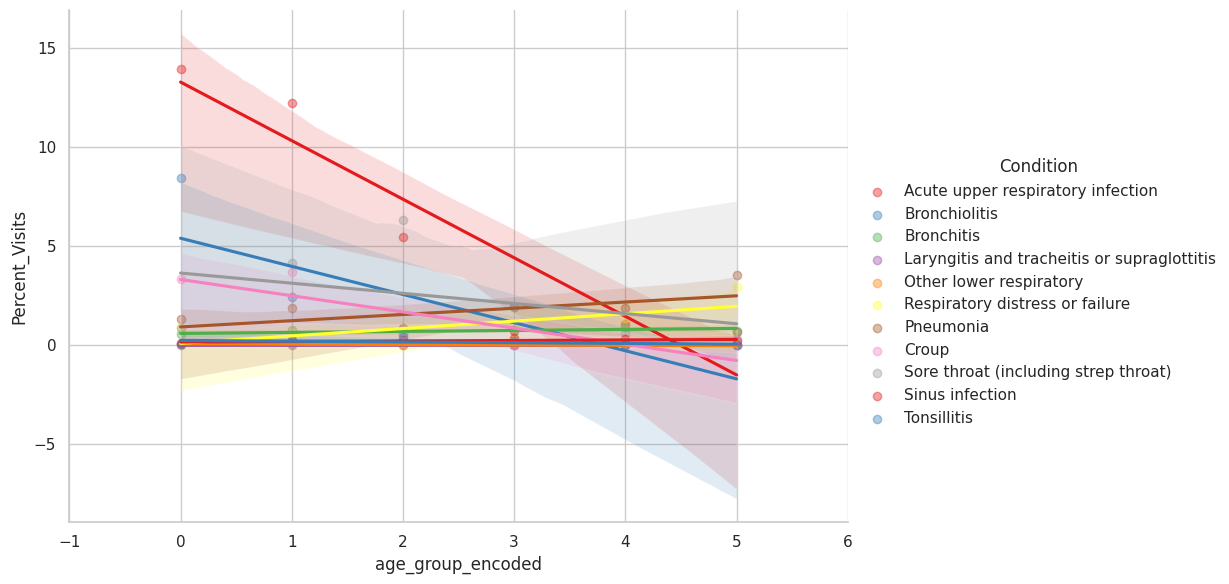

In [36]:
# Create the multi-line regression plot
g = sns.lmplot(
    data=df_long,
    x='age_group_encoded',
    y='Percent_Visits',
    hue='Condition',      # This creates one line per condition
    aspect=1.5,           # Makes the plot wider
    height=6,
    scatter_kws={'alpha': 0.4},
    palette='Set1'        # Distinct colors for each line
)

# Fix the X-axis labels to show Age Groups instead of 0, 1, 2...
age_labels = ['Infants 0-1', 'Kids 2-4', 'Kids 5-17', 'Adults 18-49', 'Adults 50-64', 'Seniors 65+']
g.set_xticklabels(age_labels, rotation=45)

plt.title('Comparison of Respiratory Trends Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Percentage of ED Visits')
plt.show()

In [37]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# To check whether percent visits influenced by age group and condition:
model = smf.ols(formula="Percent_Visits ~ C(age_group_encoded) + C(Condition)", data=df_long).fit()

# This produces the full multiple regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Percent_Visits   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     3.145
Date:                Wed, 29 Apr 2026   Prob (F-statistic):            0.00118
Time:                        15:01:26   Log-Likelihood:                -135.59
No. Observations:                  66   AIC:                             303.2
Df Residuals:                      50   BIC:                             338.2
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

Inference:
There is a significant "drop-off" in respiratory ED visit percentages once patients leave the youngest childhood brackets. Adults and older children have roughly a 2% lower visit share than infants.

In [38]:
import statsmodels.api as sm

# List of conditions you want to analyze
conditions = [
    'Acute upper respiratory infection',
    'Bronchiolitis',
    'Bronchitis',
    'Laryngitis and tracheitis or supraglottitis',
    'Other lower respiratory',
    'Respiratory distress or failure',
    'Pneumonia',
    'Croup',
    'Sore throat (including strep throat)',
    'Sinus infection',
    'Tonsillitis'
]

# Ensure we are using the filtered data (excluding 'Overall')
# And that our X is a float for the math engine
df_regression['age_group_encoded'] = df_regression['age_group_encoded'].astype(float)

for cond in conditions:
    print(f"\n{'='*10} REGRESSION SUMMARY: {cond} {'='*10}")

    # Define Independent Variable (X) and Dependent Variable (y)
    X = df_regression['age_group_encoded']
    y = df_regression[cond]

    # Statsmodels needs an explicit 'constant' (intercept) added
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()

    # Print the specific metrics we care about
    print(model.summary().tables[1]) # The coefficient table
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"P-value for Age Group: {model.pvalues[1]:.4f}")


========== REGRESSION SUMMARY: Acute upper respiratory infection ==========
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                13.2929      1.570      8.468      0.001       8.934      17.651
age_group_encoded    -2.9571      0.518     -5.703      0.005      -4.397      -1.518
R-squared: 0.8905
P-value for Age Group: 0.0047

========== REGRESSION SUMMARY: Bronchiolitis ==========
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.4083      1.676      3.227      0.032       0.755      10.061
age_group_encoded    -1.4200      0.554     -2.565      0.062      -2.957       0.117
R-squared: 0.6220
P-value for Age Group: 0.0623

========== REGRESSION SUMMARY: Bronchitis ==========
                        coef

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/tmp/ipykernel_5339/1019166176.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"P-value for Age Group: {model.pvalues[1]:.4f}")
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/tmp/ipykernel_5339/1019166176.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent

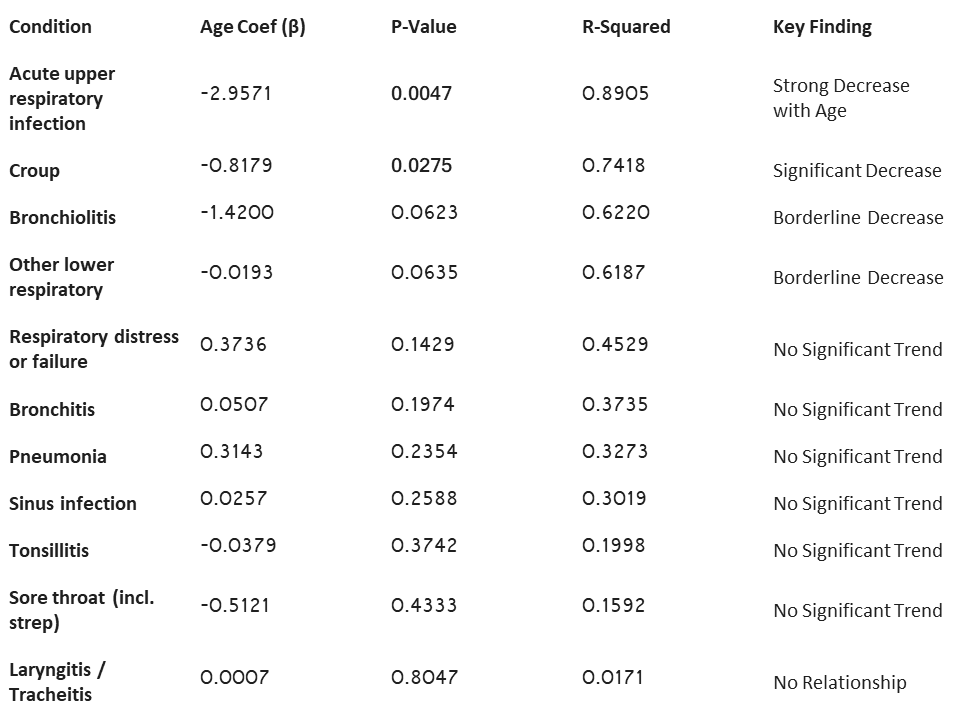



# To perform k-means cluster analysis:

In [39]:
from numpy.random import RandomState
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

condition = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

X = df_age[condition]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize and fit the model:
kmeans = KMeans(n_clusters=3, random_state=43)

df_age['Cluster'] = kmeans.fit_predict(X_scaled)

# Print the results:
print(df_age[['age_group', 'Cluster']])

      age_group  Cluster
0  Adults 18-49        0
1  Adults 50-64        0
2   Infants 0-1        1
3      Kids 2-4        1
4     Kids 5-17        0
5       Overall        0
6   Seniors 65+        2


In [40]:
# This shows the 'Center' of each cluster
print(df_age.groupby('Cluster')[condition].mean())


         Acute upper respiratory infection  Bronchiolitis  Bronchitis  \
Cluster                                                                 
0                                   2.8000        0.16875     0.76875   
1                                  13.1125        5.45000     0.66250   
2                                   0.6750        0.02500     0.75000   

         Pneumonia    Croup  Sinus infection  \
Cluster                                        
0          1.29375  0.21875             0.30   
1          1.61250  3.55000             0.15   
2          3.57500  0.00000             0.20   

         Sore throat (including strep throat)  Tonsillitis  
Cluster                                                     
0                                      2.6875       0.1875  
1                                      2.5125       0.1625  
2                                      0.3000       0.0000  


# Key takeaway:

Cluster 1 represents high-volume acute infections (Croup/Bronchiolitis), while Cluster 2 is specifically defined by Pneumonia risk. This confirms that ER resources should not be spread thin across all conditions, but instead targeted toward the specific 'signature' diseases of each patient cluster.

# To determine whether there is any significant difference in ED visits between these age groups, regardless of whether it follows a trend?"

In [41]:
# Melt the dataframe into long format:

df_anova = pd.melt(df, id_vars=['week_end', 'age_group'],
                    var_name='Condition',
                    value_name='Average ED visits per weekend')

# Fill the missing age groups removing NaN:

# This turns the NaNs into "Adults 18-49" for all relevant rows
df_anova['age_group'] = df_anova['age_group'].ffill()

# Ensure there are no leftover NaNs in the numeric column
df_anova = df_anova.dropna(subset=['Average ED visits per weekend'])


df_anova.head()


,week_end,age_group,Condition,Average ED visits per weekend
0,2023-10-01,Adults 18-49,Acute upper respiratory infection,1.925
1,2023-11-01,Adults 18-49,Acute upper respiratory infection,2.425
2,2023-12-01,Adults 18-49,Acute upper respiratory infection,3.020
3,2024-01-01,Adults 18-49,Acute upper respiratory infection,2.650
4,2024-02-01,Adults 18-49,Acute upper respiratory infection,2.275


In [42]:
# To perform One-Way ANOVA:

import pandas as pd
import scipy.stats as stats

groups = [group['Average ED visits per weekend'].values for name, group in df_anova.groupby('age_group')]

f_stat, p_val = stats.f_oneway(*groups)

print(f"One-Way ANOVA Results: F={f_stat:.4f}, p_value={p_val:.4e}")



One-Way ANOVA Results: F=0.0004, p_value=1.0000e+00


In [43]:
# 1. List ALL columns that are NOT respiratory illnesses in id_vars
# This prevents 'Year', 'age_min', etc., from being mixed into the percentages
df_anova = pd.melt(df,
                    id_vars=['week_end', 'age_group', 'Year'],
                    var_name='Condition',
                    value_name='Average_ED_visits')

# 2. Clean up: Remove the 'Overall' group
# (You shouldn't compare 'Overall' against specific groups in ANOVA as it's a duplicate of their data)
df_anova = df_anova[df_anova['age_group'] != 'Overall']

# 3. Fill and drop as before
df_anova['age_group'] = df_anova['age_group'].ffill()
df_anova = df_anova.dropna(subset=['Average_ED_visits'])

# 4. Re-run the ANOVA
groups = [group['Average_ED_visits'].values for name, group in df_anova.groupby('age_group')]
f_stat, p_val = stats.f_oneway(*groups)

print(f"New ANOVA Result: F={f_stat:.4f}, p-value={p_val:.4e}")

New ANOVA Result: F=38.5680, p-value=5.1340e-38


Age Really Matters (Demographic Sensitivity)
The math shows that it is not a coincidence that some age groups visit the ER more than others.

Supporting the conclusion from the cluster analysis:
The very low p-value tells that the patterns seen—like infants getting sicker than middle-aged adults—are a solid, repeating trend, not just a one-time fluke or lucky guess.

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
Adults 18-49 Adults 50-64   0.0468 0.9998 -0.4457  0.5393  False
Adults 18-49  Infants 0-1   1.7789    0.0  1.2863  2.2714   True
Adults 18-49     Kids 2-4   1.4441    0.0  0.9516  1.9367   True
Adults 18-49    Kids 5-17   0.4938 0.0129   0.066  0.9216   True
Adults 18-49  Seniors 65+   0.2818 0.5774 -0.2107  0.7743  False
Adults 50-64  Infants 0-1    1.732    0.0  1.2395  2.2245   True
Adults 50-64     Kids 2-4   1.3973    0.0  0.9048  1.8898   True
Adults 50-64    Kids 5-17    0.447 0.0346  0.0192  0.8748   True
Adults 50-64  Seniors 65+   0.2349 0.7506 -0.2576  0.7274  False
 Infants 0-1     Kids 2-4  -0.3347 0.3789 -0.8272  0.1578  False
 Infants 0-1    Kids 5-17   -1.285    0.0 -1.7128 -0.8572   True
 Infants 0-1  Seniors 65+  -1.4971    0.0 -1.9896 -1.0046   True
    Kids 2-4    Kids 5-17

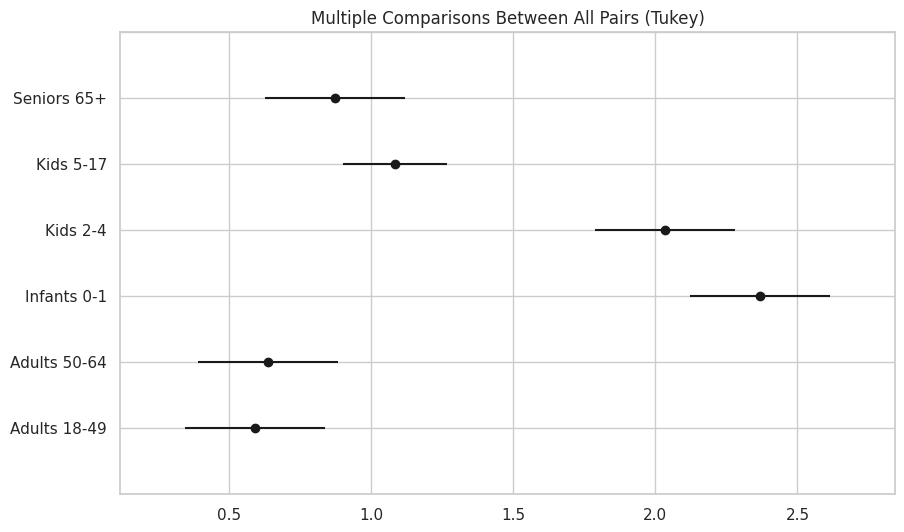

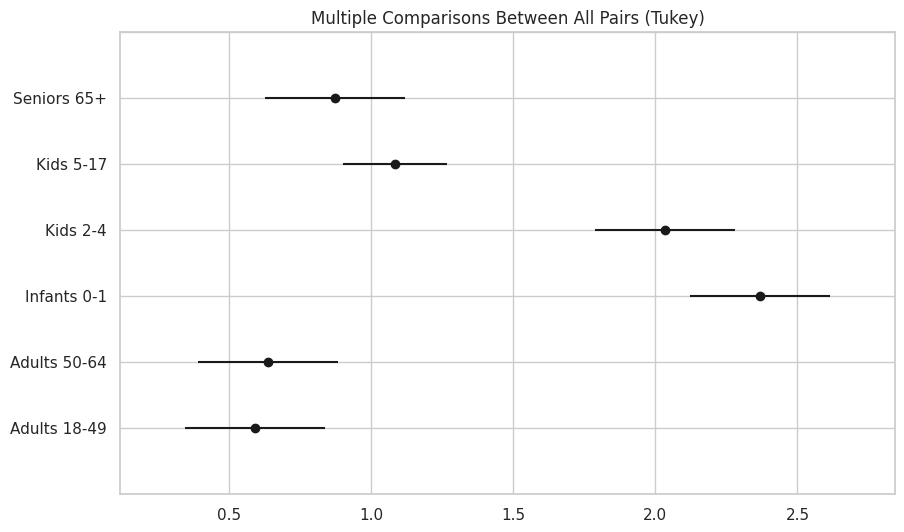

In [44]:
# This test compares every age group against every other age group to see where the specific differences lie.

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run the Tukey HSD test
# endog = your numeric data, groups = your categories
tukey = pairwise_tukeyhsd(endog=df_anova['Average_ED_visits'],
                          groups=df_anova['age_group'],
                          alpha=0.05)

# Print the results table
print(tukey)

# Optional: Plot the results to see the differences visually
tukey.plot_simultaneous()

The Post-Hoc Tukey HSD test identified a clear hierarchy in ED visit frequency. Infants (0-1) and Toddlers (2-4) experienced the highest rates, with no statistical difference between them. School-aged children (5-17) occupied a middle tier, while all Adult groups (18 to 65+) showed the lowest visit rates with no significant variation between the adult sub-categories.

In [45]:
# To perform Two-Way ANOVA using Age group and Condition for ED visits:

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Q("Average_ED_visits") ~ C(age_group) * C(Condition)', data=df_anova).fit()

# Peform Two-Way ANOVA:
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)


                                sum_sq      df           F         PR(>F)
C(age_group)                885.433773     5.0  302.592897  9.595793e-244
C(Condition)               3879.007677    10.0  662.816467   0.000000e+00
C(age_group):C(Condition)  4725.602836    50.0  161.495291   0.000000e+00
Residual                   1216.695324  2079.0         NaN            NaN


In [49]:
# Installing the pingouin
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.1 MB/s eta 0:00:00


The analysis confirms that the outcome is not determined by any single factor in isolation. While Age Group and Condition are both significant, the Interaction Effect is the dominant force ($sum\_sq = 4725.60$).

This massive interaction proves a high state of interdependency: the "adverseness" of a condition depends on the age of the individual, and the impact of aging depends on which condition is present.

In [52]:
print(df_anova.columns.tolist())

['week_end', 'age_group', 'Year', 'Condition', 'Average_ED_visits', 'combined']


In [53]:
# Calculating Eta-squared to determine the strength of each factor:

import pingouin as pg

aov = pg.anova(data=df_anova, dv='Average_ED_visits', between=['age_group', 'Condition'], detailed= True)
print(aov[['Source', 'SS', 'np2']])

                  Source           SS       np2
0              age_group   885.433773  0.421208
1              Condition  3879.007677  0.761231
2  age_group * Condition  4725.602836  0.795248
3               Residual  1216.695324       NaN


To effectively reduce ER visits, Age and Condition should not be looked as separate issues. They are deeply linked. Understanding this interdependency is the key to providing better care and managing our hospital more efficiently.

Due to interaction being significant, performing post-hoc test gives better picture after Two-Way ANOVA summary:

In [46]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_anova['combined'] = df_anova['age_group'].astype(str) + '_' + df_anova['Condition'].astype(str)

tukey = pairwise_tukeyhsd(endog=df_anova['Average_ED_visits'],
                          groups=df_anova['combined'],
                          alpha=0.05)
tukey.summary()


group1,group2,meandiff,p-adj,lower,upper,reject
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Bronchiolitis,-1.8896,0.0,-2.7333,-1.046,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Bronchitis,-1.1457,0.0,-1.9893,-0.302,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Croup,-1.9118,0.0,-2.7554,-1.0682,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Laryngitis and tracheitis or supraglottitis,-1.8644,0.0,-2.708,-1.0208,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Other lower respiratory,-1.91,0.0,-2.7536,-1.0664,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Pneumonia,-0.9229,0.0108,-1.7665,-0.0792,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Respiratory distress or failure,-1.5764,0.0,-2.42,-0.7328,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Sinus infection,-1.5632,0.0,-2.4068,-0.7196,True
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Sore throat (including strep throat),-0.0439,1.0,-0.8875,0.7997,False
Adults 18-49_Acute upper respiratory infection,Adults 18-49_Tonsillitis,-1.7055,0.0,-2.5491,-0.8619,True


In [47]:
# To clean up the data, it needs to be re-ran to further fed into the sorting code:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# RE-RUN THIS FIRST
tukey = pairwise_tukeyhsd(endog=df_anova['Average_ED_visits'],
                          groups=df_anova['combined'],
                          alpha=0.05)# Cleaning up the data:

import pandas as pd
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])


# Filter for only significant results:
significant_results = tukey_df[tukey_df['reject']== True].sort_values(by='meandiff', ascending=False)

print(significant_results.head(20))

                                                 group1  \
210                                  Adults 18-49_Croup   
826                                  Adults 50-64_Croup   
1155                           Adults 50-64_Tonsillitis   
331                Adults 18-49_Other lower respiratory   
925                Adults 50-64_Other lower respiratory   
876   Adults 50-64_Laryngitis and tracheitis or supr...   
85                           Adults 18-49_Bronchiolitis   
723                          Adults 50-64_Bronchiolitis   
271   Adults 18-49_Laryngitis and tracheitis or supr...   
616                            Adults 18-49_Tonsillitis   
1066                       Adults 50-64_Sinus infection   
448        Adults 18-49_Respiratory distress or failure   
505                        Adults 18-49_Sinus infection   
1111  Adults 50-64_Sore throat (including strep throat)   
148                             Adults 18-49_Bronchitis   
775                             Adults 50-64_Bronchitis 

Filtering the data with infants since the dominating group is infants:

In [48]:
no_infants = significant_results[significant_results['group2'].str.contains('Infants')]
print(no_infants.head(10))

                                                 group1  \
210                                  Adults 18-49_Croup   
826                                  Adults 50-64_Croup   
1155                           Adults 50-64_Tonsillitis   
331                Adults 18-49_Other lower respiratory   
925                Adults 50-64_Other lower respiratory   
876   Adults 50-64_Laryngitis and tracheitis or supr...   
85                           Adults 18-49_Bronchiolitis   
723                          Adults 50-64_Bronchiolitis   
271   Adults 18-49_Laryngitis and tracheitis or supr...   
616                            Adults 18-49_Tonsillitis   

                                             group2  meandiff  p-adj    lower  \
210   Infants 0-1_Acute upper respiratory infection   12.7677    0.0  11.9241   
826   Infants 0-1_Acute upper respiratory infection   12.7677    0.0  11.9241   
1155  Infants 0-1_Acute upper respiratory infection   12.7661    0.0  11.9225   
331   Infants 0-1_Acute up

Inference from Post-HOC Tukey's test:  

The most glaring inference is that Infants (0-1) with Acute Upper Respiratory Infections are the dominant outliers in the entire study. Every single one of the top 20 significant differences compares a group to these infants.

Inference: Regardless of the condition adults have (Croup, Bronchitis, Pneumonia, etc.), infants with a common upper respiratory infection utilize the ED at a rate that is vastly and significantly higher. Majority of resources were utilized by infants.

# Random Forest generation:

 Based on TWO-Way ANOVA results, significant interaction between age group and condition, Random Forest can be generated.

/tmp/ipykernel_5339/1144817040.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


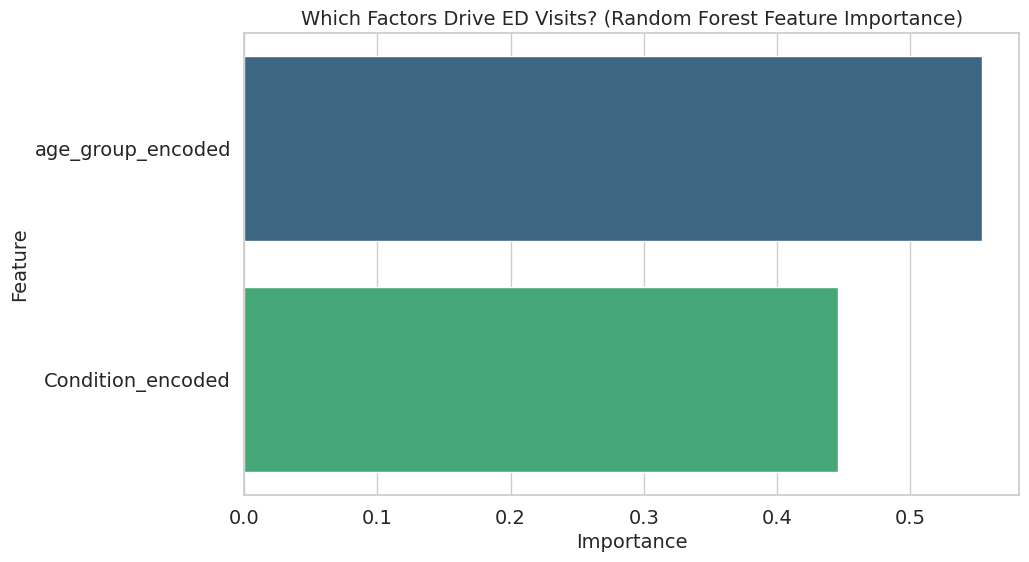

             Feature  Importance
0  age_group_encoded    0.554212
1  Condition_encoded    0.445788


In [54]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data:
df_rf = df_anova.copy()

# Label encoding:
le_age = LabelEncoder()
le_cond = LabelEncoder()

df_rf['age_group_encoded'] = le_age.fit_transform(df_rf['age_group'])
df_rf['Condition_encoded'] = le_cond.fit_transform(df_rf['Condition'])

# Define Features (X) and Target (y)
X = df_rf[['age_group_encoded', 'Condition_encoded']]
y = df_rf['Average_ED_visits']

# Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Build and Train the Random Forest
# n_estimators=100 means we are using 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# Check Feature Importance
# This tells us which factor was the most "predictive"
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest', fontsize=14)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Which Factors Drive ED Visits? (Random Forest Feature Importance)', fontsize=14)
plt.show()

print(feature_importance_df)

# Inference:
Age Group is the primary predictor—accounting for over 50% of the predictive importance—it primarily acts as a vulnerability marker, specifically for infants (0-1) and toddlers (2-4) who represent the dataset's dominant outliers.

The secondary driver, Condition Type (approximately 45% importance), identifies the specific clinical triggers—most notably Acute Upper Respiratory Infection and Bronchiolitis—that mobilize these vulnerable age groups to seek emergency care.

The chart suggests that age-based targeting is the slightly more powerful lever for this specific model.

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Ensure the data is prepared
df_nb = df_anova.copy()

# Define the Formula
# 'C()' tells the model to treat age_group and Condition as categorical
formula = 'Average_ED_visits ~ C(age_group) + C(Condition)'

# 3. Fit the Negative Binomial Model
# We use smf.glm with the NegativeBinomial family
# This is mathematically more robust for the "waves" and "hotspots" in your data
nb_model = smf.glm(formula=formula,
                   data=df_nb,
                   family=sm.families.NegativeBinomial()).fit()

# 4. Print the Summary
print("--- Negative Binomial Regression Summary ---")
print(nb_model.summary())

# 5. Extracting the Log-Likelihood to compare with your previous ANOVA
print(f"\nLog-Likelihood: {nb_model.llf:.2f}")
print("A higher Log-Likelihood indicates a better fit for the high-variance peaks.")

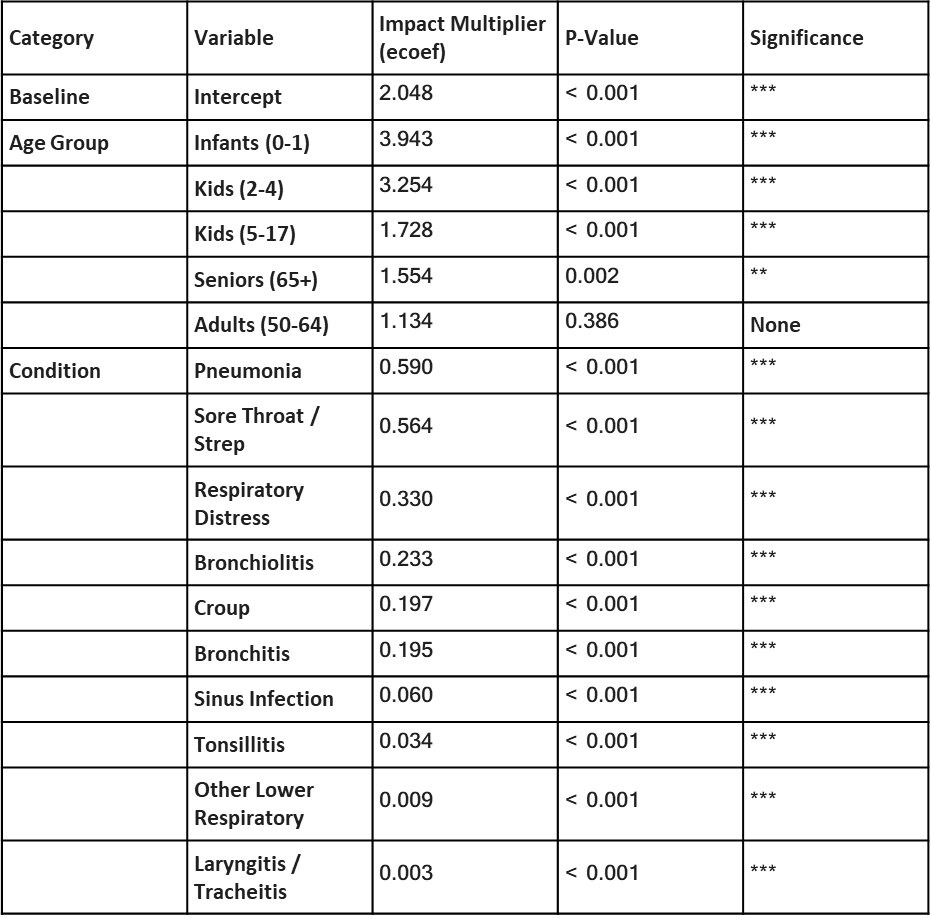

$2.048 \text{ (Base)} \times 3.943 \text{ (Age)} \times 0.590 \text{ (Pneumonia)}$ - **4.76 **predicted visits by infant group

Interpretation: Resource allocation should be heavily weighted toward infants and young children, as they represent the highest volume.
Infants (0-1) have the highest positive coefficient (1.3716). This means infants have significantly higher rates of ED visits compared to young adults.

Kids (2-4) follow closely behind (1.1800).

Adults 50-64 is the only group where the result is not statistically significant ($P>|z|$ is 0.386). This means their visit rate isn't meaningfully different from the baseline young adult group.